Simulating hands and extracting features...
Collected 969 states. Feature vector size: 43


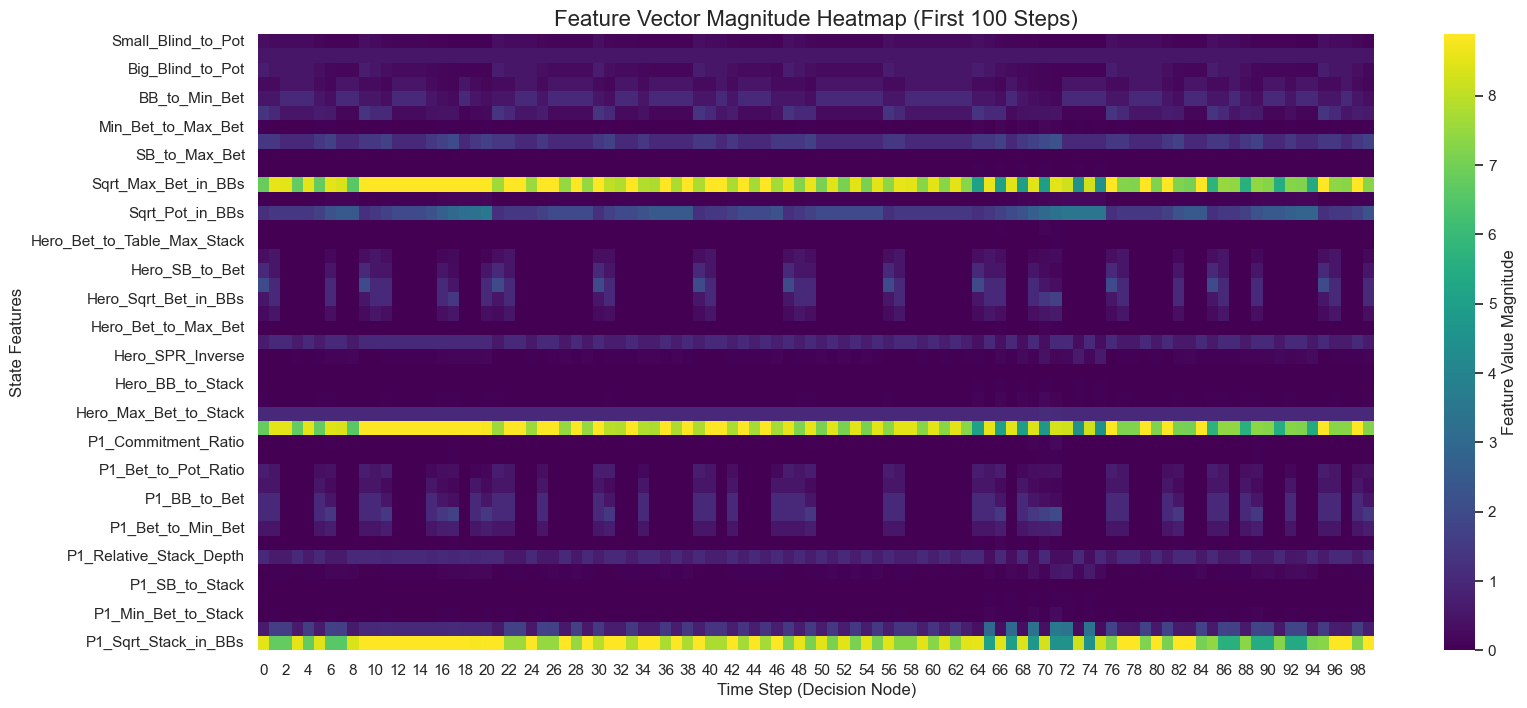

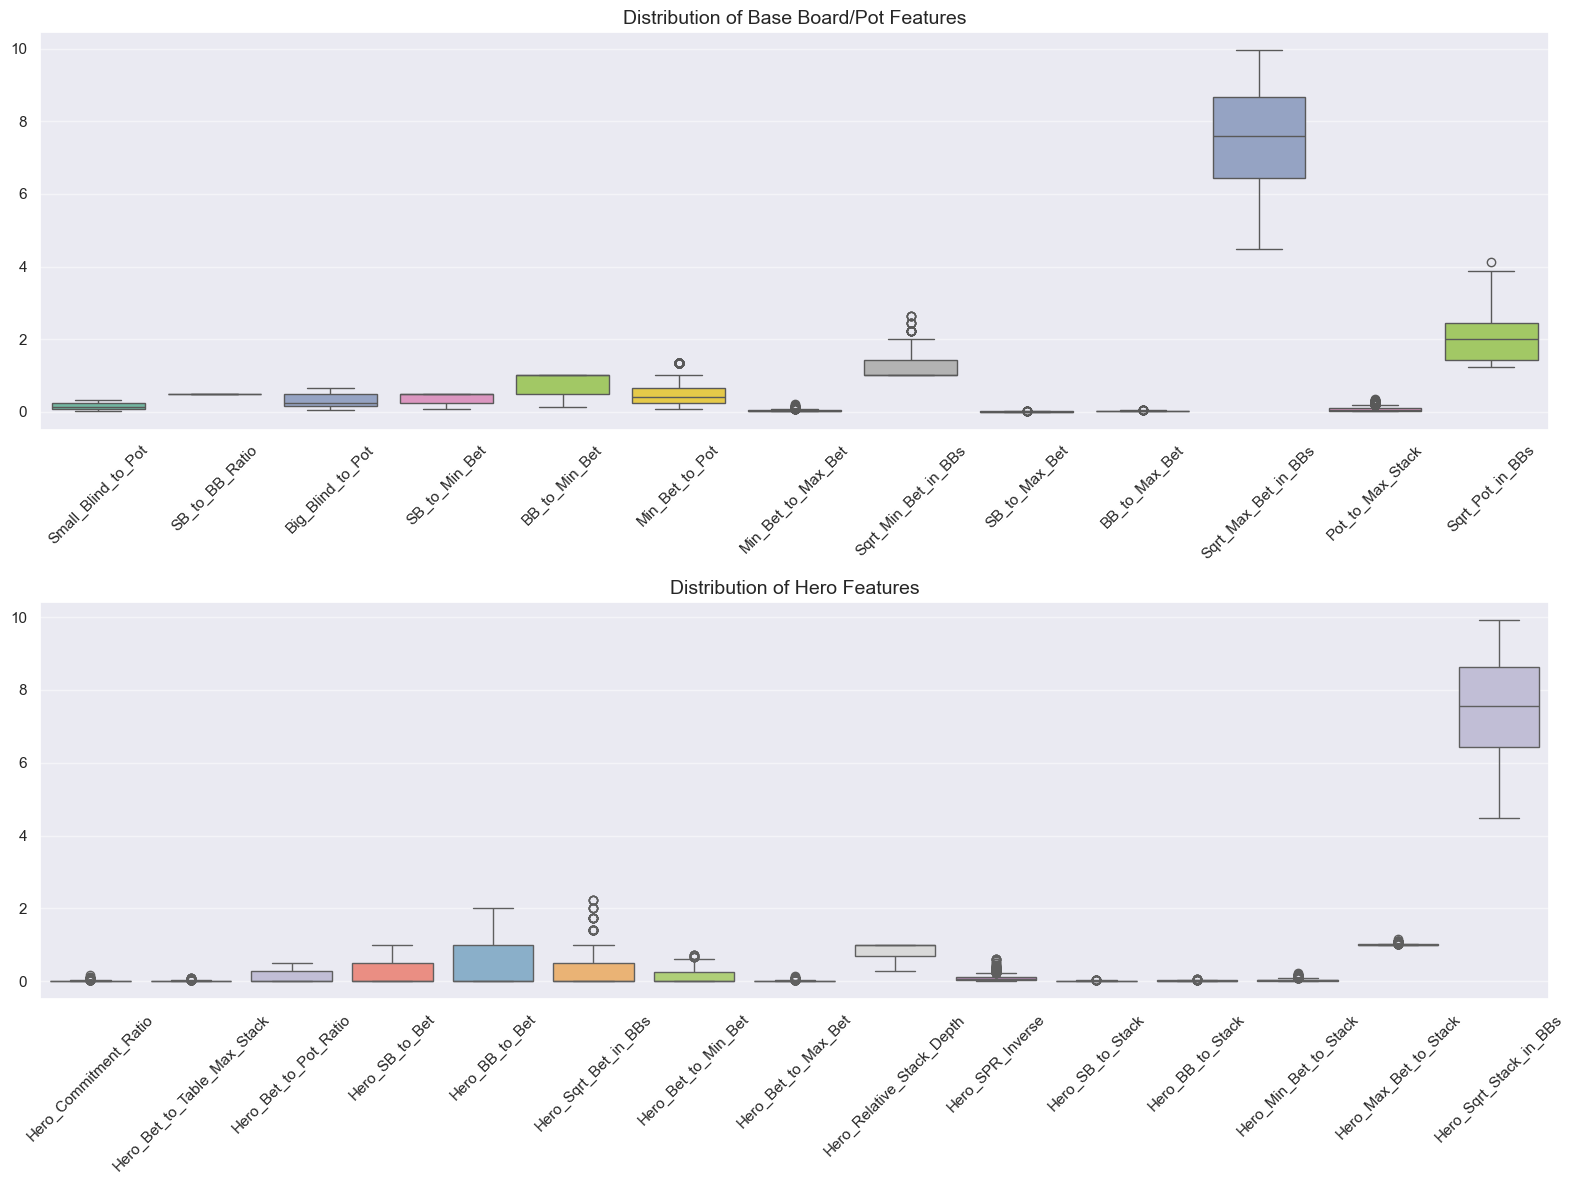

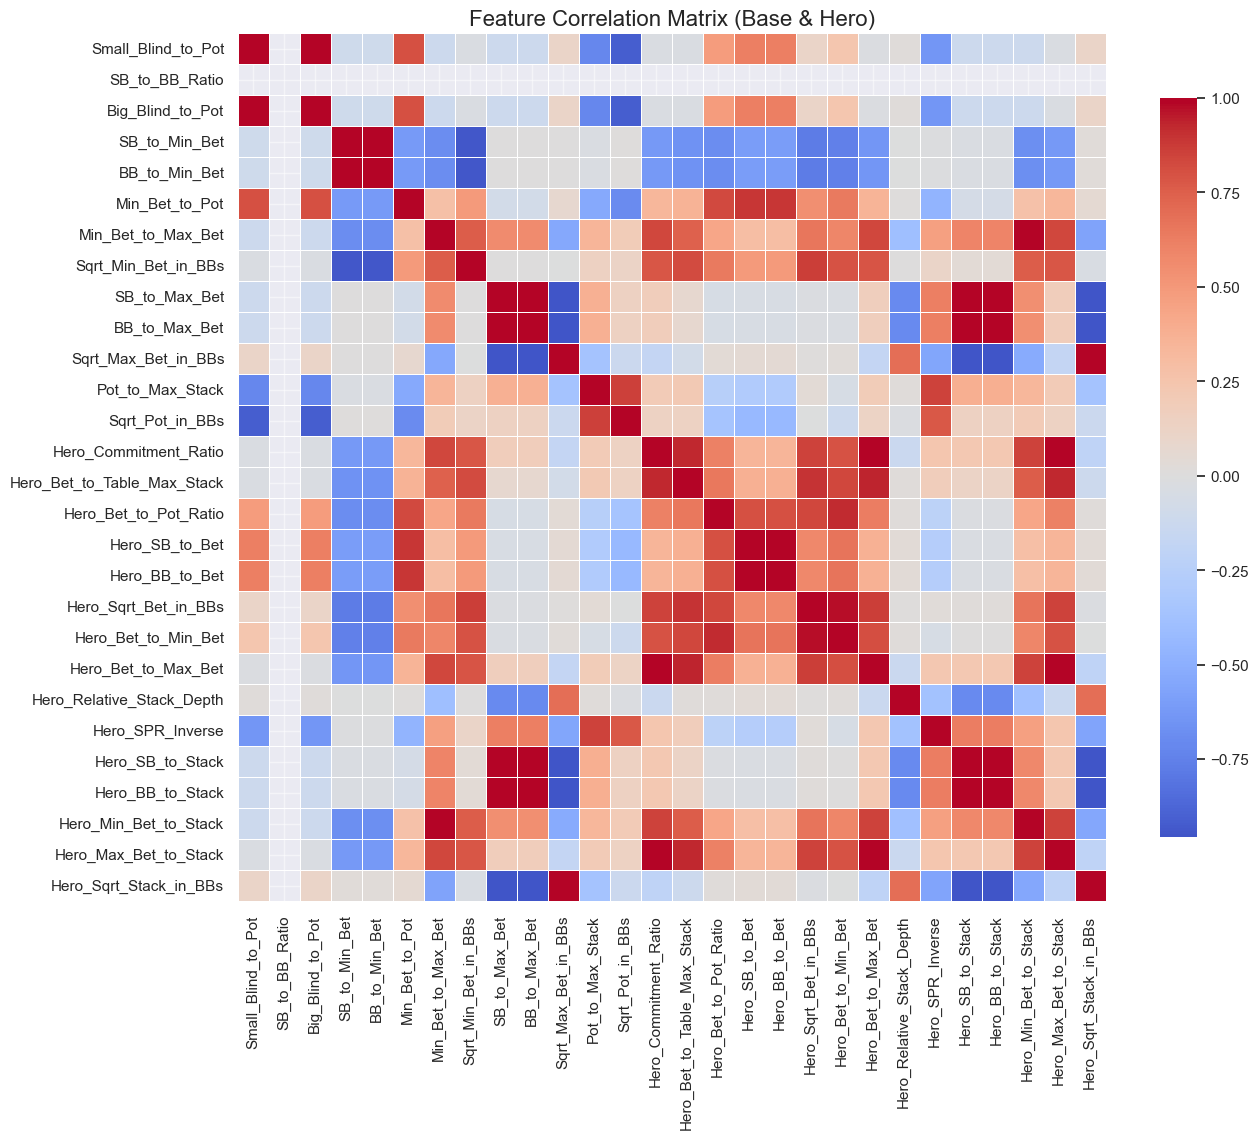

==== DEAD FEATURE DIAGNOSTIC ====
⚠️ WARNING: Found 1 features with ZERO variance.
These features provide no signal to the network and act as dead weight.

🚨 CRITICAL DEAD FEATURES (Active Players/Board):
  - SB_to_BB_Ratio

==== FEATURE MAGNITUDE WARNINGS ====
✅ All features are safely bounded below the 10,000 threshold.


In [2]:
# %% [markdown]
# # Poker AI: Input Feature Diagnostics
# This notebook generates random poker states, processes them through the `StatePreprocessor`,
# and visualizes the statistical health of the input vectors feeding into the neural networks.

# %%
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PokerKit & Local Imports ---
from pokerkit import NoLimitTexasHoldem, Automation
from src.state_interpreter import StatePreprocessor, extract_state_snapshot
from src.ppo_self_play.global_settings import MAX_TABLE_SIZE

# Configure Seaborn for better visuals
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)

# %% [markdown]
# ### 1. Data Generation
# We simulate several hands of poker and collect the preprocessed `float_features` at every decision point.

# %%
def generate_sample_states(num_hands=50, table_size=2):
    preprocessor = StatePreprocessor(max_num_players=MAX_TABLE_SIZE)
    collected_features = []

    for _ in range(num_hands):
        starting_stacks = [random.randint(50, 200) for _ in range(table_size)]

        state = NoLimitTexasHoldem.create_state(
            (
                Automation.ANTE_POSTING, Automation.BET_COLLECTION, Automation.BLIND_OR_STRADDLE_POSTING,
                Automation.CARD_BURNING, Automation.HOLE_DEALING, Automation.BOARD_DEALING,
                Automation.HOLE_CARDS_SHOWING_OR_MUCKING, Automation.HAND_KILLING,
                Automation.CHIPS_PUSHING, Automation.CHIPS_PULLING,
            ),
            ante_trimming_status=True, raw_antes=0, raw_blinds_or_straddles=(1, 2),
            min_bet=2, raw_starting_stacks=starting_stacks, player_count=table_size
        )

        while state.status:
            actor = state.actor_index

            # Process state through your pipeline
            processed_dict = preprocessor.process(state, actor)
            collected_features.append(processed_dict["float_features"])

            # Take a random valid action to progress the state
            if state.can_check_or_call():
                if state.can_complete_bet_or_raise_to() and random.random() > 0.7:
                    s_min = state.min_completion_betting_or_raising_to_amount
                    state.complete_bet_or_raise_to(s_min)
                else:
                    state.check_or_call()
            else:
                state.fold()

    return np.array(collected_features)

print("Simulating hands and extracting features...")
feature_matrix = generate_sample_states(num_hands=100, table_size=MAX_TABLE_SIZE)
print(f"Collected {feature_matrix.shape[0]} states. Feature vector size: {feature_matrix.shape[1]}")

# --- Semantic Feature Mapping ---
base_feature_names = [
    "Small_Blind_to_Pot", "SB_to_BB_Ratio", "Big_Blind_to_Pot",
    "SB_to_Min_Bet", "BB_to_Min_Bet", "Min_Bet_to_Pot",
    "Min_Bet_to_Max_Bet", "Sqrt_Min_Bet_in_BBs", "SB_to_Max_Bet",
    "BB_to_Max_Bet", "Sqrt_Max_Bet_in_BBs", "Pot_to_Max_Stack",
    "Sqrt_Pot_in_BBs"
]

player_feature_names = [
    "Commitment_Ratio", "Bet_to_Table_Max_Stack", "Bet_to_Pot_Ratio",
    "SB_to_Bet", "BB_to_Bet", "Sqrt_Bet_in_BBs",
    "Bet_to_Min_Bet", "Bet_to_Max_Bet", "Relative_Stack_Depth",
    "SPR_Inverse", "SB_to_Stack", "BB_to_Stack",
    "Min_Bet_to_Stack", "Max_Bet_to_Stack", "Sqrt_Stack_in_BBs"
]

# Construct the full column list dynamically based on MAX_TABLE_SIZE
columns = list(base_feature_names)
for p in range(MAX_TABLE_SIZE):
    prefix = "Hero_" if p == 0 else f"P{p}_"
    columns.extend([f"{prefix}{feat}" for feat in player_feature_names])

df = pd.DataFrame(feature_matrix, columns=columns)

# %% [markdown]
# ### 2. Temporal Magnitude Heatmap
# This visualizes the raw magnitudes of the feature vector across the first 100 decision steps.
# **What to look for:** Bright vertical streaks (indicating a feature is consistently outputting massive numbers) or entirely blank columns (dead features).

# %%
plt.figure(figsize=(18, 8))
# Slicing the first 100 steps for clarity
sns.heatmap(df.iloc[:100].T, cmap="viridis", robust=True, cbar_kws={'label': 'Feature Value Magnitude'})
plt.title("Feature Vector Magnitude Heatmap (First 100 Steps)", fontsize=16)
plt.xlabel("Time Step (Decision Node)", fontsize=12)
plt.ylabel("State Features", fontsize=12)
plt.show()

# %% [markdown]
# ### 3. Distribution & Outlier Detection (Boxplots)
# We group the features into Base Features and Player 0 (Hero) features to check for exploding scaling.
# **What to look for:** If one box is squished at the bottom while another stretches to 10,000, your `safe_div` limits are too loose and neural network gradients will warp.

# %%
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot Base Features
base_cols = df.columns[:len(base_feature_names)]
sns.boxplot(data=df[base_cols], ax=axes[0], palette="Set2")
axes[0].set_title("Distribution of Base Board/Pot Features", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Plot Player 0 (Hero) Features
hero_cols = [col for col in df.columns if col.startswith("Hero_")]
sns.boxplot(data=df[hero_cols], ax=axes[1], palette="Set3")
axes[1].set_title("Distribution of Hero Features", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4. Feature Correlation Matrix
# **What to look for:** Large dark red/blue squares. If two features have a correlation of 1.0 or -1.0, they are perfectly redundant. The network is wasting weights processing identical information.

# %%
# We look at the correlation of Base + Hero to keep the matrix readable
subset_cols = list(base_cols) + list(hero_cols)
corr_matrix = df[subset_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Matrix (Base & Hero)", fontsize=16)
plt.show()

# %% [markdown]
# ### 5. The "Dead Feature" Diagnostic
# Automatically scans the preprocessed data to flag features that have zero variance (they never change from a static number, usually 0).

# %%
print("==== DEAD FEATURE DIAGNOSTIC ====")
variances = df.var()
dead_features = variances[variances == 0].index.tolist()

if len(dead_features) > 0:
    print(f"⚠️ WARNING: Found {len(dead_features)} features with ZERO variance.")
    print("These features provide no signal to the network and act as dead weight.")

    # Check if they are just empty seats due to padding
    empty_seat_features = [f for f in dead_features if not f.startswith("Small_") and not f.startswith("Hero_") and not f.startswith("P1_") and not f in base_feature_names]

    if empty_seat_features:
        print(f"  -> {len(empty_seat_features)} of these belong to Players 2+, which is expected if MAX_TABLE_SIZE is large but games are Heads-Up.")

    core_dead_features = [f for f in dead_features if f not in empty_seat_features]
    if core_dead_features:
        print("\n🚨 CRITICAL DEAD FEATURES (Active Players/Board):")
        for f in core_dead_features:
            print(f"  - {f}")
else:
    print("✅ No dead features detected in the active data set.")

print("\n==== FEATURE MAGNITUDE WARNINGS ====")
# Flag features that hit the 10,000 max_val limit in safe_div
max_vals = df.max()
capped_features = max_vals[max_vals >= 9999.0].index.tolist()
if capped_features:
    print(f"⚠️ WARNING: Found {len(capped_features)} features hitting the safe_div max_val cap (10,000).")
    print("Consider scaling these down (e.g., using safe_lin_sqrt or safe_log).")
    for f in capped_features:
        print(f"  - {f} (Max: {max_vals[f]:.1f})")
else:
    print("✅ All features are safely bounded below the 10,000 threshold.")